In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples
# trimmed_transcriptome = transcriptome.drop(index=all_unsable)
# trimmed_metadata = metadata.drop(index=all_unsable)
## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome
defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_defense_genes_union_GO_and_FLG.csv"
)

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [8]:
defense_gene_list

,gene
0,AT1G01100
1,AT1G01230
2,AT1G04510
3,AT1G07360
4,AT1G08450
...,...
194,AT5G64810
195,AT5G65200
196,AT5G67300
197,AT5G67330


In [9]:
defense_transcriptome = trimmed_transcriptome.loc[
    :, trimmed_transcriptome.columns.isin(defense_gene_list["gene"])
]

In [10]:
defense_transcriptome

,AT1G01100,AT1G01230,AT1G04510,AT1G07360,AT1G08450,AT1G08830,AT1G09560,AT1G09770,AT1G10480,AT1G17290,...,AT5G59790,AT5G60600,AT5G60950,AT5G61210,AT5G63840,AT5G64810,AT5G65200,AT5G67300,AT5G67330,AT5G67500
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,787.136213,34.095974,31.160016,34.047459,45.475142,850.800354,41.167223,19.222598,2.573651,23.457956,...,6.955278,35.890910,8.202360,4.536004,8.531534,11.595469,5.097092,57.089665,21.670451,42.838398
A2450525897_n01_LICRNA01_B01,1203.196364,39.645926,31.214444,38.095571,18.556950,996.993639,51.001813,11.522192,2.559687,47.671746,...,5.423981,31.499752,2.753277,6.955064,7.031120,3.978732,2.975539,44.318045,21.869829,35.256441
A2450525897_n01_LICRNA01_C01,1180.542941,65.251943,54.394753,48.882159,47.919718,1457.047013,110.137890,14.118166,8.040061,80.272715,...,7.449678,32.492753,21.743878,39.879654,6.411323,24.218426,2.670362,70.924278,26.331630,48.407055
A2450525897_n01_LICRNA01_E01,1199.355814,27.699144,28.629564,36.953868,7.987771,598.329305,57.455636,7.482511,1.280851,69.909283,...,5.034902,24.773096,3.061606,4.138701,8.628894,2.769993,3.474197,42.122914,17.808721,24.304532
A2450525897_n01_LICRNA01_F01,888.648000,57.988074,39.988750,34.731605,60.312963,1028.302429,76.537443,23.485200,15.285066,38.235219,...,11.060936,43.323726,16.740008,15.184138,9.093726,11.719773,7.322698,104.513307,30.617141,28.309987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,735.130580,8.689104,19.349887,28.674303,21.582138,521.422625,16.881569,8.503379,0.000000,27.653369,...,1.077765,39.975312,0.699055,4.009036,5.668321,0.000000,1.510974,45.637873,2.690143,16.064164
A2534491401_n01_LICRNA05_E12,575.866112,9.763463,15.347367,20.586787,15.555908,613.902079,26.092246,5.780721,0.000000,12.491009,...,1.220116,25.371757,6.043309,2.785019,3.548456,1.464561,0.058314,5.473229,6.085590,18.261069
A2534491401_n01_LICRNA05_F12,722.137699,14.005907,24.779249,35.642752,38.459295,1408.021610,36.370101,14.213228,0.861423,36.267905,...,10.562544,36.741061,1.909302,5.934939,6.443894,4.953701,1.820676,12.786071,5.036853,16.658597


In [21]:
defense_corr = defense_transcriptome.corr(method="spearman")
np.fill_diagonal(defense_corr.values, 0)
defense_corr

,AT1G01100,AT1G01230,AT1G04510,AT1G07360,AT1G08450,AT1G08830,AT1G09560,AT1G09770,AT1G10480,AT1G17290,...,AT5G59790,AT5G60600,AT5G60950,AT5G61210,AT5G63840,AT5G64810,AT5G65200,AT5G67300,AT5G67330,AT5G67500
AT1G01100,0.000000,0.199130,0.539535,0.498691,0.128295,0.275149,0.167926,0.322251,0.204252,0.426015,...,0.280437,0.179675,0.047993,0.152004,0.197255,0.092178,0.112099,0.370119,0.337567,0.310401
AT1G01230,0.199130,0.000000,0.276442,0.396703,0.287702,0.436481,0.344586,0.379483,0.240265,0.387678,...,0.356754,0.253049,0.085446,0.423114,0.260361,0.253210,0.266175,0.345198,0.388488,0.298019
AT1G04510,0.539535,0.276442,0.000000,0.590871,-0.020467,0.281285,0.175078,0.447706,0.267022,0.426572,...,0.412966,0.081890,-0.093056,0.176865,0.093926,0.082388,0.176365,0.317840,0.399916,0.347684
AT1G07360,0.498691,0.396703,0.590871,0.000000,0.043448,0.350735,0.274207,0.524029,0.328899,0.579031,...,0.522271,0.127477,-0.034411,0.347468,0.207848,0.160542,0.298959,0.445164,0.480149,0.395974
AT1G08450,0.128295,0.287702,-0.020467,0.043448,0.000000,0.528290,0.496430,0.228879,0.138772,0.063116,...,0.155269,0.477326,0.441041,0.524908,0.363524,0.518253,0.186335,0.122814,0.156348,0.163374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G64810,0.092178,0.253210,0.082388,0.160542,0.518253,0.364600,0.477627,0.201544,0.202255,0.206820,...,0.256405,0.181221,0.365577,0.499076,0.208088,0.000000,0.239951,0.107699,0.101850,0.126221
AT5G65200,0.112099,0.266175,0.176365,0.298959,0.186335,0.249168,0.123751,0.337674,0.257120,0.168346,...,0.349348,0.207542,0.063580,0.350362,0.233751,0.239951,0.000000,0.189446,0.300471,0.230482
AT5G67300,0.370119,0.345198,0.317840,0.445164,0.122814,0.432667,0.276386,0.288703,0.200632,0.335428,...,0.404140,0.269152,0.059898,0.299197,0.177213,0.107699,0.189446,0.000000,0.400621,0.342092
AT5G67330,0.337567,0.388488,0.399916,0.480149,0.156348,0.388743,0.137171,0.439733,0.279433,0.291129,...,0.513625,0.254198,0.034716,0.304679,0.291812,0.101850,0.300471,0.400621,0.000000,0.435870


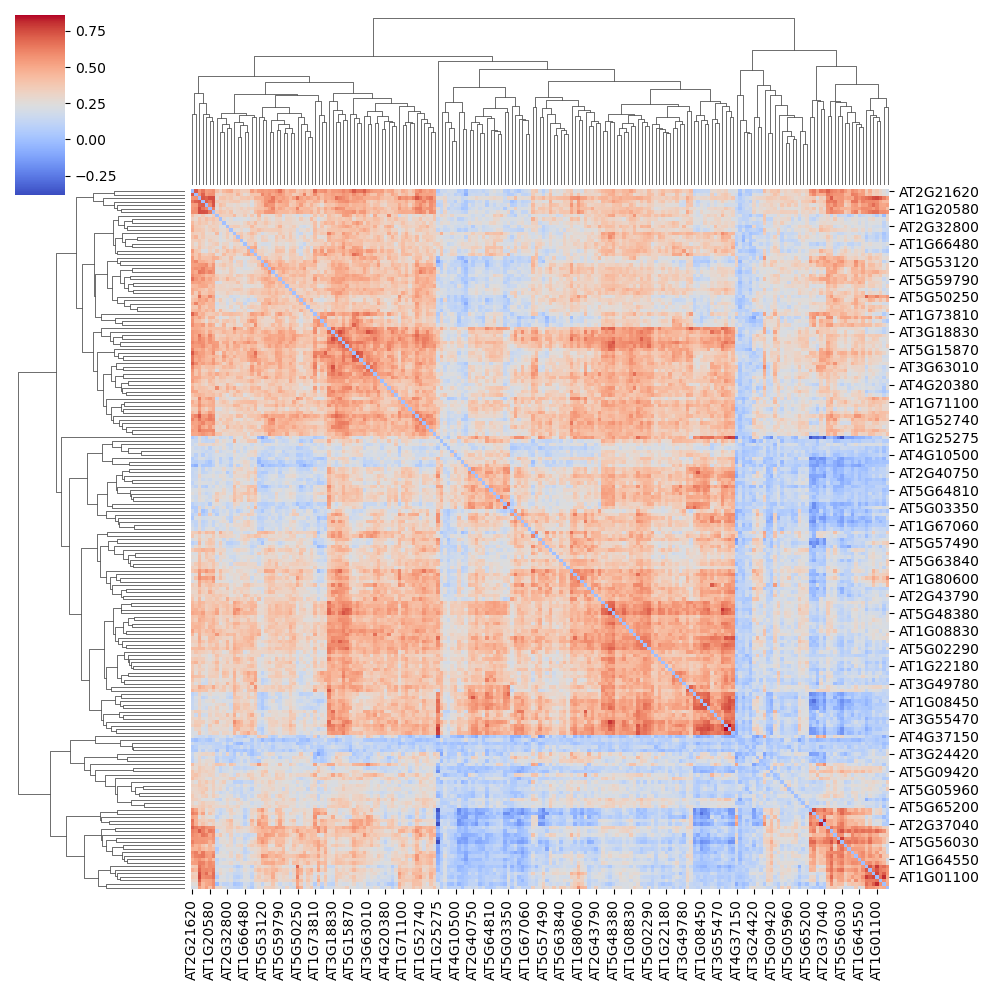

In [22]:
sns.clustermap(
    defense_corr,
    cmap="coolwarm",
)